## Emotion Recognition Using CNN for Masked Faces

The purpose of the project Emotion Recognition Using CNN for Masked Faces is to address a real and practical limitation of conventional facial emotion recognition systems that emerged prominently during the COVID-19 era.
We trained a CNN model using masked facial images of size 48×48.
The model learns emotional features primarily from the upper face region such as eyes and eyebrows. 
Given a new masked image, it predicts the emotion along with confidence percentage.

In [1]:
# pip install tensorflow numpy opencv-python matplotlib pillow jupyter scipy

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam


D:\python apps\masked_emotion_analysis\venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
BASE_DIR = "masked_dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "validation")

IMG_SIZE = 48
BATCH_SIZE = 64
EPOCHS = 25

EMOTIONS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)


Found 15531 images belonging to 7 classes.
Found 4953 images belonging to 7 classes.


In [5]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(7, activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


D:\python apps\masked_emotion_analysis\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 46, 46, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 46, 46, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 23, 23, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 21, 21, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 21, 21, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 10, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 356,743 (1.36 MB)

 Trainable params: 356,295 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)


Epoch 1/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 215s 875ms/step - accuracy: 0.1946 - loss: 2.0270 - val_accuracy: 0.1290 - val_loss: 2.3065
Epoch 2/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - accuracy: 0.2193 - loss: 1.8500 - val_accuracy: 0.2590 - val_loss: 1.7994
Epoch 3/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - accuracy: 0.2423 - loss: 1.8178 - val_accuracy: 0.2627 - val_loss: 1.7620
Epoch 4/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - accuracy: 0.2623 - loss: 1.7941 - val_accuracy: 0.2901 - val_loss: 1.7199
Epoch 5/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - accuracy: 0.2685 - loss: 1.7720 - val_accuracy: 0.2722 - val_loss: 1.7282
Epoch 6/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - accuracy: 0.2796 - loss: 1.7510 - val_accuracy: 0.2804 - val_loss: 1.7418
Epoch 7/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - accuracy: 0.2851 - loss: 1.7421 - val_accuracy: 0.2992 - val_loss: 1.7196
Epoch 8/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - accuracy: 0.2966 - loss: 1.7219 

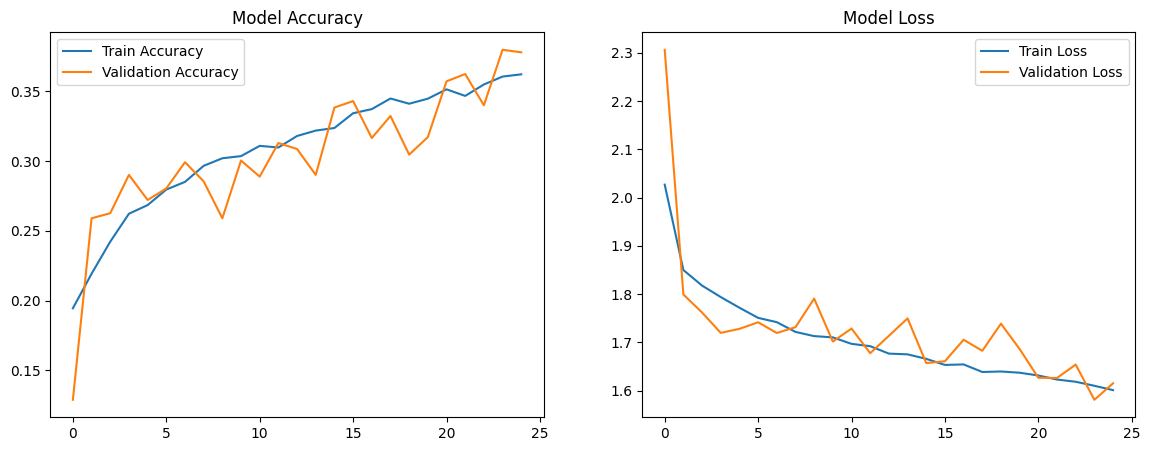

In [8]:
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()

plt.show()


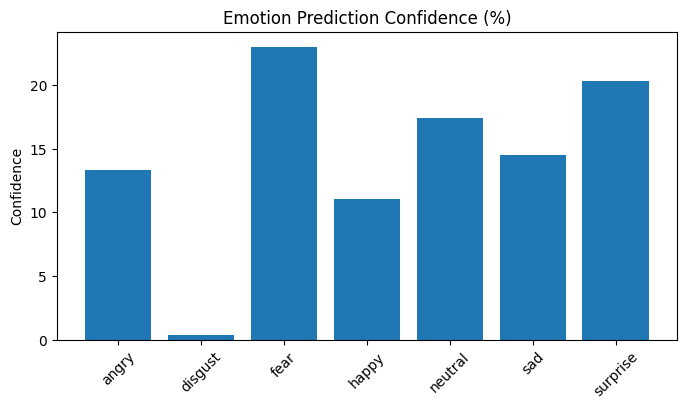

In [33]:
plt.figure(figsize=(8,4))
plt.bar(EMOTIONS, probs * 100)
plt.title("Emotion Prediction Confidence (%)")
plt.ylabel("Confidence")
plt.xticks(rotation=45)
plt.show()


In [9]:
model.save("masked_emotion_cnn.h5")


In [31]:


def predict_emotion(image_path, model):
    # 1. Validate path
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")

    # 2. Read image (grayscale)
    img_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        raise ValueError("Unable to read image. Unsupported format or corrupted file.")

    # 3. Resize & normalize
    img_resized = cv2.resize(img_gray, (48, 48))
    img_norm = img_resized / 255.0
    img_input = np.reshape(img_norm, (1, 48, 48, 1))

    # 4. Model prediction
    predictions = model.predict(img_input)[0]
    emotion_index = np.argmax(predictions)
    emotion = EMOTIONS[emotion_index]
    confidence = predictions[emotion_index] * 100

    # 5. Display image
    plt.figure(figsize=(4,4))
    plt.imshow(img_gray, cmap='gray')
    plt.title(f"Predicted: {emotion} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    # 6. Confidence bar chart
    plt.figure(figsize=(8,4))
    plt.bar(EMOTIONS, predictions * 100)
    plt.ylabel("Confidence (%)")
    plt.title("Emotion Prediction Probabilities")
    plt.xticks(rotation=45)
    plt.ylim(0, 100)
    plt.show()

    return emotion, confidence


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


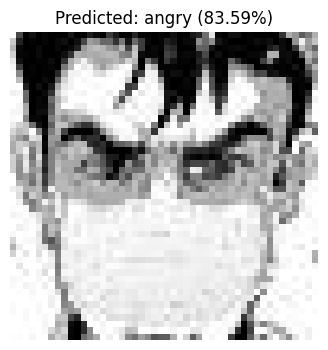

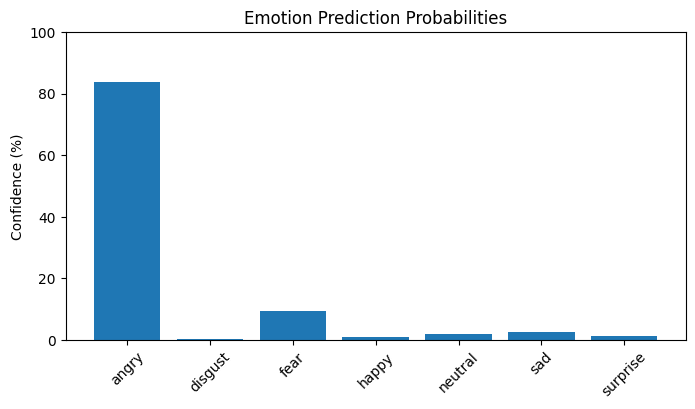

Predicted Emotion : angry
Confidence        : 83.59%


In [32]:
IMAGE_PATH = r"D:\python apps\masked_emotion_analysis\angry2.jpg"

emotion, confidence = predict_emotion(IMAGE_PATH, model)

print(f"Predicted Emotion : {emotion}")
print(f"Confidence        : {confidence:.2f}%")
